In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx # we will use it for visualization
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from scipy.optimize import milp
from scipy import optimize
from scipy.sparse.csgraph import shortest_path

## Stationary Enviroment

**What Requirement 2 has.** For campaign $i$ there are $k_i$ competitors, each bidding $U(0,1)$, so the highest competing bid is

$$
m_i(t) = \max_{j=1,\dots,k_i} u_{ij}(t), \qquad u_{ij}(t) \sim U(0,1) \;\Rightarrow\; m_i(t) \sim \text{Beta}(k_i, 1), \quad \Pr[b \ge m_i(t)] = b^{\,k_i}.
$$

The whole distribution is characterised by one integer $k_i$: more competitors pushes the max toward 1 and makes winning harder. That is the parameter to make time-varying.

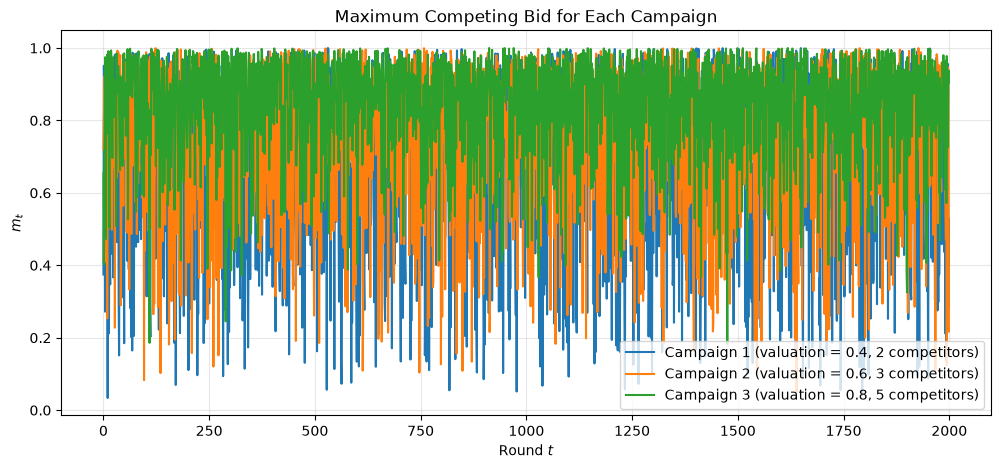

Campaign valuations: [0.4 0.6 0.8]
Number of competitors: [2, 3, 5]
Shape of m_t: (3, 2000)
Budget per round: 0.15


In [ ]:
# Reproducibility
np.random.seed(42)

# Problem parameters
n_campaigns = 3
n_users = 2000  # Number of rounds
B = 300
rho = B / n_users

# Different valuation for each campaign
my_valuations = np.array([0.6, 0.7, 0.8])

# Different number of competitors for each campaign
n_competitors = [2, 3, 5]

# Generate uniformly distributed bids for each campaign
other_bids = [
    np.random.uniform(
        0,
        1,
        size=(n_competitors[campaign], n_users)
    )
    for campaign in range(n_campaigns)
]

# Maximum competing bid for each campaign and round
m_t = np.array([
    campaign_bids.max(axis=0)
    for campaign_bids in other_bids
])

# Plot the maximum competing bid for each campaign
plt.figure(figsize=(12, 5))

for campaign in range(n_campaigns):
    plt.plot(
        m_t[campaign],
        label=(
            f"Campaign {campaign + 1} "
            f"(valuation = {my_valuations[campaign]}, "
            f"{n_competitors[campaign]} competitors)"
        )
    )

plt.title("Maximum Competing Bid for Each Campaign")
plt.xlabel("Round $t$")
plt.ylabel("$m_t$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Campaign valuations:", my_valuations)
print("Number of competitors:", n_competitors)
print("Shape of m_t:", m_t.shape)
print("Budget per round:", rho)

**Requirement 3: same generator, with $k_i(t)$ changing quickly.** Keep the uniform bidders, but let the number of competitors in campaign $i$ at round $t$ be a fixed, pre-specified sequence $k_i(t)$:

$$
m_i(t) = \max_{j=1,\dots,k_i(t)} u_{ij}(t), \qquad u_{ij}(t) \sim U(0,1), \qquad m_i(t) \sim \text{Beta}(k_i(t), 1).
$$

Then the win probability of bid $b$ is $b^{\,k_i(t)}$, which changes with $t$. The simplest way to make $k_i(t)$ "change quickly" is to cycle it through a short list every few rounds, i.e. a periodic schedule with a period much smaller than $T$:

$$
k_i(t) = \kappa_i\!\left[\, \left\lfloor \tfrac{t}{L_i} \right\rfloor \bmod |\kappa_i| \right], \qquad \text{e.g. } \kappa_1 = (1, 6),\; \kappa_2 = (2, 8, 4),\; \kappa_3 = (10, 1, 5),\; L_i \in \{10, 20, 30\}.
$$

So:
1. campaign 1 alternates between 1 $\kappa_1 = (1, 6)$ and 6 competitors every 10 rounds $L_1=10$, 
2. campaign 2 cycles through 2, 8, 4 $\kappa_2 = (2, 8, 4)$ every 20 rounds $L_2=20$, and so on. 

Each campaign uses a different list $\kappa_i$ and a different interval length $L_i$, so the campaigns are not synchronised. With $T = 2000$ and $L_i \le 30$ there are dozens of regime changes per campaign, which is what makes the environment *highly* non-stationary.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility: the sequence is generated ONCE and then treated as fixed
# (oblivious adversary) -> non-stochastic from the learner's point of view
np.random.seed(42)

# Problem parameters (same as Requirement 2)
n_campaigns = 3
n_users = 2000          # Number of rounds T
B = 300
rho = B / n_users
my_valuations = np.array([0.4, 0.6, 0.8])

# Non-stationary schedule of the number of competitors:
# campaign i cycles through kappa[i], switching every L[i] rounds
kappa = [
    [1, 3],        # campaign 1: "worth it" (k=1) vs "hard" (k=3)
    [1, 5, 3],     # campaign 2: worth it -> hard -> medium
    [6, 1, 3],     # campaign 3: hard -> worth it -> medium
]
L = [10, 20, 30] # rounds per regime (kappa) for each campaign

t = np.arange(n_users)

# k_i(t) = kappa_i[ floor(t / L_i) mod |kappa_i| ]
n_competitors_t = np.array([
    np.array(kappa[campaign])[(t // L[campaign]) % len(kappa[campaign])]
    for campaign in range(n_campaigns)
])                       # shape (n_campaigns, T)

# m_i(t) = max of k_i(t) uniform bids  ->  Beta(k_i(t), 1)
k_max = max(max(k) for k in kappa)
all_bids = np.random.uniform(0, 1, size=(n_campaigns, k_max, n_users))

m_t = np.zeros((n_campaigns, n_users))
for campaign in range(n_campaigns):
    for round_t in range(n_users):
        k = n_competitors_t[campaign, round_t]
        m_t[campaign, round_t] = all_bids[campaign, :k, round_t].max()

print("Campaign valuations:", my_valuations)
print("Schedules kappa:", kappa, "with interval lengths L:", L)
print("Shape of m_t:", m_t.shape)
print("Budget per round:", rho)

Campaign valuations: [0.4 0.6 0.8]
Schedules kappa: [[1, 3], [1, 5, 3], [6, 1, 3]] with interval lengths L: [10, 20, 30]
Shape of m_t: (3, 2000)
Budget per round: 0.15


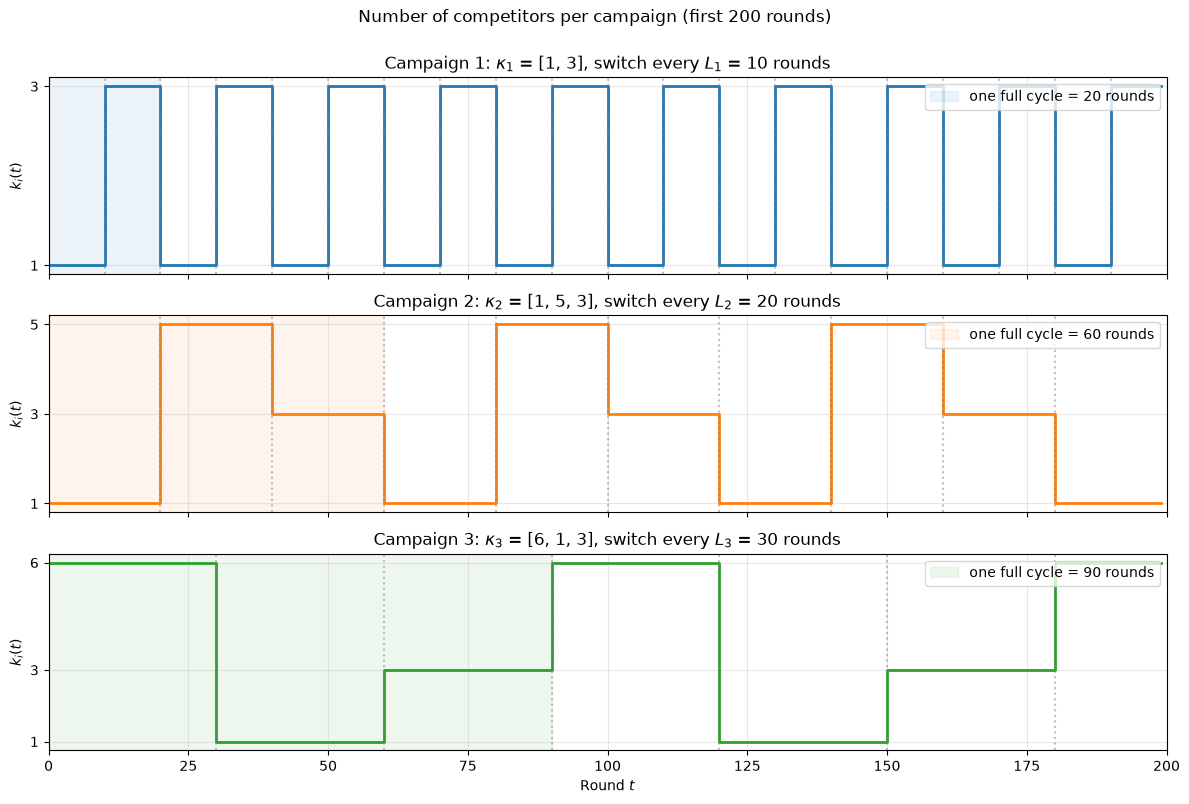

In [10]:
# ------------------------------------------------------------------
# Plot 1: k_i(t) per campaign (one subplot each) to show the cyclic behaviour
# ------------------------------------------------------------------
zoom = 200

fig, axes = plt.subplots(n_campaigns, 1, figsize=(12, 8), sharex=True)

for campaign in range(n_campaigns):
    ax = axes[campaign]
    ax.step(
        t[:zoom], n_competitors_t[campaign, :zoom],
        where="post", color=f"C{campaign}", linewidth=2
    )

    # vertical lines at every regime change
    for change in range(0, zoom, L[campaign]):
        ax.axvline(change, color="gray", linestyle=":", alpha=0.5)

    # shade one full cycle to highlight the period
    period = L[campaign] * len(kappa[campaign])
    ax.axvspan(
        0, period, color=f"C{campaign}", alpha=0.08,
        label=f"one full cycle = {period} rounds"
    )

    ax.set_yticks(sorted(set(kappa[campaign])))
    ax.set_ylabel("$k_i(t)$")
    ax.set_title(
        f"Campaign {campaign + 1}: $\\kappa_{campaign + 1}$ = {kappa[campaign]}, "
        f"switch every $L_{campaign + 1}$ = {L[campaign]} rounds"
    )
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Round $t$")
axes[-1].set_xlim(0, zoom)
plt.suptitle(f"Number of competitors per campaign (first {zoom} rounds)", y=1.0)
plt.tight_layout()
plt.show()

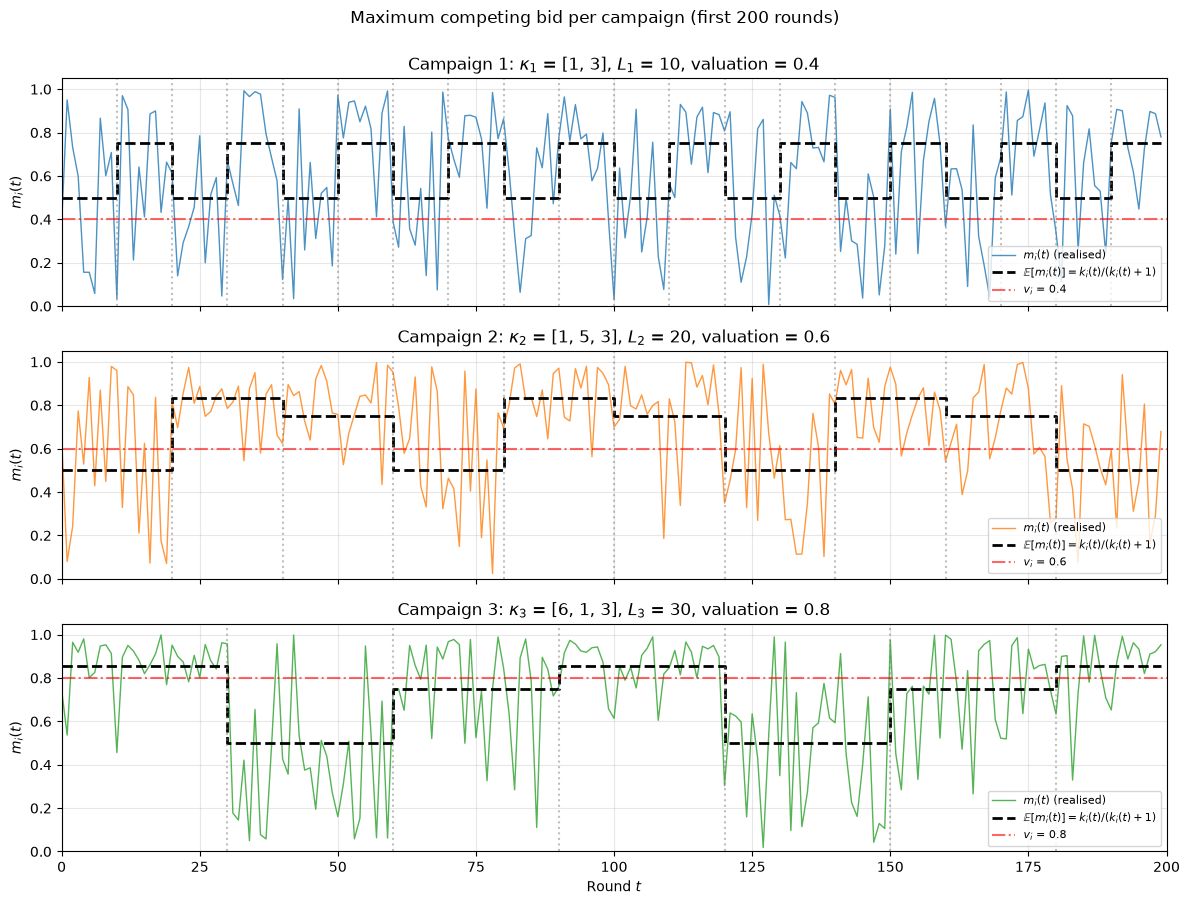

In [11]:
# ---- Plot: m_i(t) per campaign, one subplot each ----
zoom = 200

fig, axes = plt.subplots(n_campaigns, 1, figsize=(12, 9), sharex=True)

for campaign in range(n_campaigns):
    ax = axes[campaign]

    # realised highest competing bid
    ax.plot(
        t[:zoom], m_t[campaign, :zoom],
        color=f"C{campaign}", linewidth=1, alpha=0.8,
        label="$m_i(t)$ (realised)"
    )

    # mean of Beta(k, 1) is k / (k + 1): shows the regime the sample comes from
    expected_m = n_competitors_t[campaign, :zoom] / (n_competitors_t[campaign, :zoom] + 1)
    ax.step(
        t[:zoom], expected_m, where="post",
        color="black", linewidth=2, linestyle="--",
        label="$\\mathbb{E}[m_i(t)] = k_i(t) / (k_i(t) + 1)$"
    )

    # vertical lines at every regime change
    for change in range(0, zoom, L[campaign]):
        ax.axvline(change, color="gray", linestyle=":", alpha=0.5)

    # my valuation, for reference
    ax.axhline(
        my_valuations[campaign], color="red", linestyle="-.", alpha=0.6,
        label=f"$v_i$ = {my_valuations[campaign]}"
    )

    ax.set_ylim(0, 1.05)
    ax.set_ylabel("$m_i(t)$")
    ax.set_title(
        f"Campaign {campaign + 1}: $\\kappa_{campaign + 1}$ = {kappa[campaign]}, "
        f"$L_{campaign + 1}$ = {L[campaign]}, valuation = {my_valuations[campaign]}"
    )
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Round $t$")
axes[-1].set_xlim(0, zoom)
plt.suptitle(f"Maximum competing bid per campaign (first {zoom} rounds)", y=1.0)
plt.tight_layout()
plt.show()

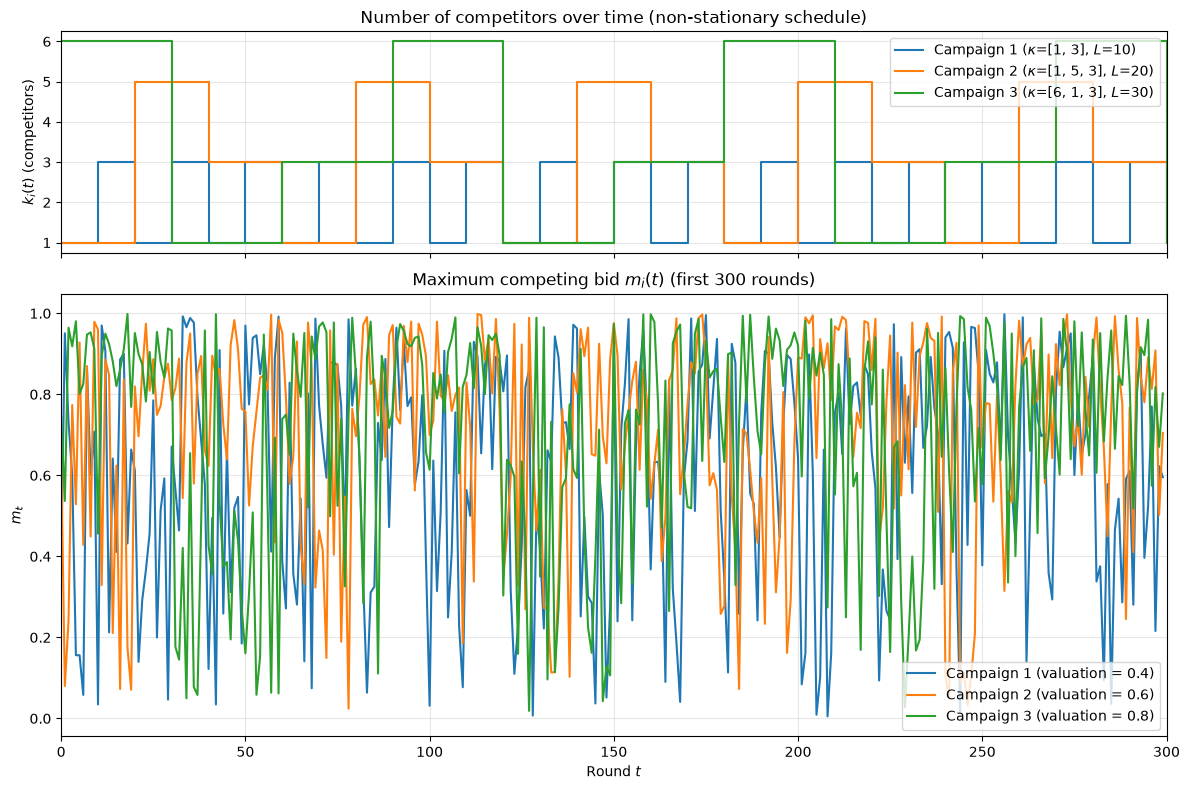

In [12]:
# ---------------- Plot ----------------
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [1, 2]})

# Top: the schedule k_i(t) that drives the distribution
for campaign in range(n_campaigns):
    axes[0].step(
        t, n_competitors_t[campaign], where="post",
        label=f"Campaign {campaign + 1} ($\\kappa$={kappa[campaign]}, $L$={L[campaign]})"
    )
axes[0].set_ylabel("$k_i(t)$ (competitors)")
axes[0].set_title("Number of competitors over time (non-stationary schedule)")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

# Bottom: realised highest competing bid, zoomed so the regimes are visible
zoom = 300
for campaign in range(n_campaigns):
    axes[1].plot(
        t[:zoom], m_t[campaign, :zoom],
        label=f"Campaign {campaign + 1} (valuation = {my_valuations[campaign]})"
    )
axes[1].set_title(f"Maximum competing bid $m_i(t)$ (first {zoom} rounds)")
axes[1].set_xlabel("Round $t$")
axes[1].set_ylabel("$m_t$")
axes[1].set_xlim(0, zoom)
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Benchmark.** Since the environment is non-stochastic, the benchmark is the best fixed strategy in hindsight on the realised sequence $m(1), \dots, m(T)$, subject to the budget:

$$
\text{OPT} = \max_{b \in \mathcal{B}^N,\; S \in \mathcal{I}(G)} \sum_{t=1}^{T} \sum_{i \in S} (v_i - b_i)\,\mathbb{1}\{b_i \ge m_i(t)\}
\quad \text{s.t.} \quad \sum_{t=1}^{T} \sum_{i \in S} b_i\,\mathbb{1}\{b_i \ge m_i(t)\} \le B,
$$

and the regret is

$$
R_T = \text{OPT} - \sum_{t=1}^{T} \sum_{i \in S_t} (v_i - b_i(t))\,\mathbb{1}\{b_i(t) \ge m_i(t)\}.
$$